# 21_因果推断基础-双重稳健估计：AIPW

## Notebook 使用说明

建议先阅读《04. 回归调整与标准化》和《06. 逆概率加权与重叠问题》。本篇需要 NumPy、pandas、Matplotlib 和 statsmodels。缺少依赖时，可在当前 Python 环境安装：`python -m pip install numpy pandas matplotlib statsmodels`。

本篇主要依据参考资料 [1] 第 12 章：先把结果预测与加权残差相加，再用四种模型设定检查双重稳健性质。[2] 第 9.3 节用于对照同一得分在因果机器学习中的位置。本篇使用事先指定的低维 Logistic 和线性模型，不将它们直接替换为机器学习模型；交叉拟合留到后续 DML 笔记。

小表、沿用第五至七篇的主模拟，以及低重叠实验均为教学构造，不是原书的实证结果。数据和图形由代码生成，不需要外部文件，也不依赖前面 Notebook 的变量或 `notebook_support.py`。这次回到全体人群 ATE，而不是上一篇的 ATT。

代码输出和图形均保存在 Notebook 中。重新运行请使用 Restart Kernel and Run All Cells。默认配置包括 999 次 Bootstrap、两种样本量下各 400 次重复模拟，以及 120 份数据各 149 次 Bootstrap 的区间实验；后者耗时较长。可以在初始化单元减少重复次数，修改后以新的输出为准。

In [1]:
# 环境初始化：本篇不读取外部数据，单独放在一个文件夹中也可以运行。
import os
import sys
import tempfile
import warnings
from pathlib import Path
from statistics import NormalDist

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib")
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
import statsmodels
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import PerfectSeparationWarning

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
    "figure.dpi": 100, "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 140)

SEED_DATA = 42
SEED_BOOT = 2026
SEED_REPEAT = 2027
SEED_COVERAGE = 2028
SEED_OVERLAP = 2029
N_MAIN = 3000
N_BOOT = 999
N_REPEATS = 400
SAMPLE_SIZES = (600, 2400)
N_COVERAGE = 120
N_COVERAGE_SAMPLE = 800
N_BOOT_COVERAGE = 149
N_OVERLAP = 1200
N_OVERLAP_REPEATS = 500
STRENGTHS = (0.5, 1.5, 3.0)
ALPHA = 0.05
Z_CRIT = NormalDist().inv_cdf(1-ALPHA/2)

print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"statsmodels {statsmodels.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
statsmodels 0.14.6


前面已经试过两种办法：结果回归为同一群人预测两种结局，逆概率加权则用处理概率重新组织比较。前者怕结果模型写错，后者怕评分模型写错。

能不能把两者放在一起，只要有一边写对，仍能估计平均效应？双重稳健估计就是这样构造的。不过，它不是把两个答案取平均，也不是“两个模型都不太准，合起来就一定准”。关键在于怎样利用已经观察到的预测误差。

下面先逐行算出预测与纠偏，再看四种模型设定。所有方法使用同一份数据，不靠更换样本解释结果差异。

## 理论基础

### 1. 这一次要把哪两个模型放在一起？

仍用 $T\in\{0,1\}$ 表示处理，$X$ 表示选定的处理前调整变量，$Y$ 表示结局。目标是：

$$
\tau=E[Y(1)-Y(0)].
$$

定义结果模型与倾向评分：

$$
\mu_t(x)=E[Y\mid T=t,X=x],\quad t=0,1,\qquad e(x)=P(T=1\mid X=x).
$$

这里说“两类模型”，不是只有两个拟合对象。评分只有一个，但结果模型要分别提供 $\mu_1$ 与 $\mu_0$。在处理定义清楚、无个体间干扰、满足一致性、条件可忽略性和重叠时，这些量可以用于识别 ATE。[1，第 12 章开头]

### 2. 先预测，再给预测误差加权

先只看所有人接受处理时的平均结局。第四篇使用 $\widehat\mu_1(X_i)$ 的平均值；现在再加上一项：

$$
\widehat M_1^{\mathrm{DR}}
=\frac1n\sum_{i=1}^n\left\{
\widehat\mu_1(X_i)+\frac{T_i}{\widehat e(X_i)}[Y_i-\widehat\mu_1(X_i)]\right\}.
$$

对每个人都保留预测；只在实际接受处理的人中计算 $Y_i-\widehat\mu_1(X_i)$，再用逆概率权重把这些误差推广到目标人群。同理：

$$
\widehat M_0^{\mathrm{DR}}
=\frac1n\sum_{i=1}^n\left\{
\widehat\mu_0(X_i)+\frac{1-T_i}{1-\widehat e(X_i)}[Y_i-\widehat\mu_0(X_i)]\right\}.
$$

两式相减，得到增广逆倾向评分加权估计（Augmented Inverse Propensity Score Weighting，AIPW），也称双重稳健估计（Doubly Robust，DR）：[1，定义 12.1]

$$
\widehat\tau_{\mathrm{AIPW}}
=\underbrace{\frac1n\sum_i[\widehat\mu_1(X_i)-\widehat\mu_0(X_i)]}_{\text{结果预测差}}
+\underbrace{\frac1n\sum_i\frac{T_i[Y_i-\widehat\mu_1(X_i)]}{\widehat e(X_i)}}_{\text{处理侧纠偏}}
-\underbrace{\frac1n\sum_i\frac{(1-T_i)[Y_i-\widehat\mu_0(X_i)]}{1-\widehat e(X_i)}}_{\text{对照侧纠偏}}.
$$

符号很长，代码里只需三列。特别注意最后一项前面的减号。

## 完整案例一：把三列贡献逐行算出来

### 1. 先不拟合模型，只看已经给出的预测

下面是 8 人的观察表。`p`、`m0`、`m1` 是人为给定的评分和两种结果预测，用来检查计算，不表示它们来自正确模型。表里没有完整潜在结局，不能据此检验真实因果效应。

In [2]:
toy = pd.DataFrame({
    "T": [1, 0, 1, 0, 1, 0, 1, 0],
    "Y": [11., 7., 14., 11., 12., 14., 11., 9.],
    "p": [0.25, 0.25, 0.50, 0.50, 0.75, 0.75, 0.60, 0.40],
    "m0": [8., 8., 10., 10., 12., 12., 9., 11.],
    "m1": [10., 10., 12., 12., 14., 14., 11., 13.],
}, index=pd.Index(range(1, 9), name="人"))
display(toy)

toy_terms = pd.DataFrame(index=toy.index)
toy_terms["预测差"] = toy["m1"]-toy["m0"]
toy_terms["处理侧纠偏"] = toy["T"]*(toy["Y"]-toy["m1"])/toy["p"]
toy_terms["对照侧纠偏（待减）"] = (1-toy["T"])*(toy["Y"]-toy["m0"])/(1-toy["p"])
toy_terms["AIPW得分"] = (toy_terms["预测差"]+toy_terms["处理侧纠偏"]
                           -toy_terms["对照侧纠偏（待减）"])
display(toy_terms.round(4))
display(toy_terms.mean().rename("列均值").to_frame().round(4))

,T,Y,p,m0,m1
人,,,,,
1,1,11.0,0.25,8.0,10.0
2,0,7.0,0.25,8.0,10.0
3,1,14.0,0.50,10.0,12.0
4,0,11.0,0.50,10.0,12.0
5,1,12.0,0.75,12.0,14.0
6,0,14.0,0.75,12.0,14.0
7,1,11.0,0.60,9.0,11.0
8,0,9.0,0.40,11.0,13.0


,预测差,处理侧纠偏,对照侧纠偏（待减）,AIPW得分
人,,,,
1,2.0,4.0000,0.0000,6.0000
2,2.0,-0.0000,-1.3333,3.3333
3,2.0,4.0000,0.0000,6.0000
4,2.0,-0.0000,2.0000,0.0000
5,2.0,-2.6667,0.0000,-0.6667
6,2.0,0.0000,8.0000,-6.0000
7,2.0,0.0000,0.0000,2.0000
8,2.0,-0.0000,-3.3333,5.3333


,列均值
预测差,2.0000
处理侧纠偏,0.6667
对照侧纠偏（待减）,0.6667
AIPW得分,2.0000


第一人实际接受了处理，观察结局为 11，预测为 10，因此处理侧纠偏是 $(11-10)/0.25=4$。第二人没有接受处理，观察结局为 7，预测为 8；对照侧纠偏为 $(7-8)/0.75=-4/3$，最后还要减去它。

每行的 AIPW 得分可以很大，也可以是负数。它是最后求平均的计算项，不是已经估计出的个体处理效应，更不是另一种已被观察到的反事实。

### 2. 和“两个估计取平均”比较

将刚才的计算封装起来，保留三部分，便于后面核对。同一个式子也能从 HT 出发写成：

$$
\widehat\tau_{\mathrm{AIPW}}
=\widehat\tau_{\mathrm{HT}}
-\frac1n\sum_i( T_i-\widehat e_i )
\left(\frac{\widehat\mu_{1i}}{\widehat e_i}
+\frac{\widehat\mu_{0i}}{1-\widehat e_i}\right).
$$

这是原书两侧增广式相减后的代数形式；不是 HT 与结果回归各占一半。[1，第 12.1–12.2 节]

In [3]:
def aipw_components(treatment, outcome, propensity, mu0, mu1):
    """逐人保留预测差、两侧加权残差与 AIPW 得分；不自动截断评分。"""
    z, y, p, m0, m1 = [np.asarray(a, dtype=float) for a in
                       (treatment, outcome, propensity, mu0, mu1)]
    if any(a.ndim != 1 for a in (z, y, p, m0, m1)):
        raise ValueError('全部输入必须是一维向量。')
    if len(z) < 2 or any(len(a) != len(z) for a in (y, p, m0, m1)):
        raise ValueError('输入必须等长，且至少有两行。')
    if not all(np.isfinite(a).all() for a in (z, y, p, m0, m1)):
        raise ValueError('输入不能包含非有限值。')
    if not np.isin(z, [0, 1]).all():
        raise ValueError('处理必须为 0/1。')
    if np.any((p <= 0) | (p >= 1)):
        raise ValueError('评分必须严格处于 0 与 1 之间；检查模型与重叠。')
    prediction = m1-m0
    correction1 = z*(y-m1)/p
    correction0 = (1-z)*(y-m0)/(1-p)
    return np.column_stack([prediction, correction1, correction0,
                            prediction+correction1-correction0])


toy_array = aipw_components(toy["T"], toy["Y"],
                             toy["p"], toy["m0"], toy["m1"])
np.testing.assert_allclose(toy_array, toy_terms.to_numpy(), atol=1e-12)
zt, yt, pt = (toy[name].to_numpy() for name in ("T", "Y", "p"))
m0t, m1t = toy["m0"].to_numpy(), toy["m1"].to_numpy()
toy_ht = np.mean(zt*yt/pt-(1-zt)*yt/(1-pt))
toy_reg = np.mean(m1t-m0t)
toy_dr = toy_array[:, 3].mean()
toy_from_ht = toy_ht-np.mean((zt-pt)*(m1t/pt+m0t/(1-pt)))
display(pd.Series({"结果回归": toy_reg, "HT": toy_ht,
                   "结果回归与HT各占一半": (toy_reg+toy_ht)/2,
                   "AIPW：预测加纠偏": toy_dr, "AIPW：从HT改写": toy_from_ht},
                  name="估计").to_frame().round(4))
np.testing.assert_allclose(toy_dr, toy_from_ht, atol=1e-12)

,估计
结果回归,2.00
HT,0.50
结果回归与HT各占一半,1.25
AIPW：预测加纠偏,2.00
AIPW：从HT改写,2.00


本表两侧纠偏的均值恰好都是 0.6667，相减后抵消，因此 AIPW 恰好等于结果回归的 2。这个相等只是本表的计算结果；HT 为 0.5，两者各占一半则为 1.25。不能据此判断哪个数接近真实效应，因为这张观察表没有提供因果真值。

## 双重稳健是怎样得到的？

### 1. 偏差里出现两个模型误差的乘积

用 $q(X)$ 表示一个可能写错的评分函数，用 $m_t(X)$ 表示可能写错的结果函数。先把它们当作固定函数，并要求 $0<q(X)<1$、有关期望存在。对处理侧：

$$
\begin{aligned}
E\left[m_1(X)+\frac{T[Y-m_1(X)]}{q(X)}\mid X\right]
&=m_1(X)+\frac{e(X)}{q(X)}[\mu_1(X)-m_1(X)]\\
&=\mu_1(X)+\frac{e(X)-q(X)}{q(X)}[\mu_1(X)-m_1(X)].
\end{aligned}
$$

第一个等号使用观察数据中的条件均值；再结合识别假设，$E[\mu_1(X)]=E[Y(1)]$。所以总体偏差为：

$$
E\left[m_1(X)+\frac{T[Y-m_1(X)]}{q(X)}\right]-E[Y(1)]
=E\left[\frac{e(X)-q(X)}{q(X)}[\mu_1(X)-m_1(X)]\right].
$$

评分正确时，第一项为零；结果正确时，第二项为零。任一条件成立，处理侧平均结局就能恢复。对照侧同理。[1，定理 12.1 及其证明]

### 2. “一边正确”究竟指什么？

| 评分模型 | 两组结果模型 | AIPW 对 ATE 的一致性保证 |
|---|---|---|
| 正确 | 正确 | 有 |
| 错误 | 都正确 | 有 |
| 正确 | 可以错误 | 有 |
| 错误 | 不能保证两组都正确 | 没有一般保证 |

这里的“正确”是模型能表达对应的真实函数，且估计在适当正则条件下收敛到它。不是说一次拟合就得到真系数，也不是“至少一个指标看起来不错”。评分错误时，只把一组结果模型写对，不足以保证两侧之差正确。[1，定理 12.1，第 12.1.2 节]

如果只把结果回归与 IPW 各占一半，正确的那一半并不能自动消掉另一半的偏差。AIPW 的保证来自上面的乘积结构。

双重稳健也没有放宽无未测混杂、处理定义或重叠假设。这里抵抗的是两类统计模型的部分错设，不是所有因果分析错误。

## 完整案例二：同一份数据，四种模型设定

### 1. 沿用前几篇的数据生成规则

为了接上已经做过的结果回归和加权分析，仍取相互独立的 $X_1,X_2\sim\operatorname{Uniform}(-1,1)$、$X_3\sim\operatorname{Bernoulli}(0.5)$：

$$
\begin{aligned}
\eta(X)&=-0.4+X_1-0.5X_2+0.6X_3+1.8(X_1^2-1/3)+1.2X_1X_2,\\
e(X)&=\operatorname{expit}\{\eta(X)\},\qquad T\mid X\sim\operatorname{Bernoulli}\{e(X)\},\\
\mu_0(X)&=10+2X_1+1.5X_2+2X_3+6X_1^2+3X_1X_2,\\
\tau(X)&=2+0.5X_1+0.8X_3,\\
Y(0)&=\mu_0(X)+\varepsilon,\quad Y(1)=Y(0)+\tau(X),\quad\varepsilon\sim N(0,1).
\end{aligned}
$$

外生随机项相互独立，总体 ATE 为 $2+0.8\times0.5=2.4$。观察数据与真值分开返回；拟合只使用 $X,T,Y$。

Ding 第 12.3.2 节通过改变生成机制形成四种场景。本篇保留它的四种比较，但固定上述生成机制，改为增删工作模型中的二次项和交互项。下面的数值是本篇模拟结果，不是原书表格的复现。

In [4]:
def expit(value):
    return np.exp(-np.logaddexp(0.0, -np.asarray(value, dtype=float)))


def make_observational_data(n: int, seed: int):
    if isinstance(n, bool) or not isinstance(n, (int, np.integer)) or n < 20:
        raise ValueError('n 必须是至少为 20 的整数。')
    rng = np.random.default_rng(seed)
    x1, x2 = rng.uniform(-1, 1, n), rng.uniform(-1, 1, n)
    x3 = rng.binomial(1, 0.5, n)
    eta = -0.4+x1-0.5*x2+0.6*x3+1.8*(x1**2-1/3)+1.2*x1*x2
    p = expit(eta)
    t = rng.binomial(1, p)
    mu0 = 10+2*x1+1.5*x2+2*x3+6*x1**2+3*x1*x2
    tau = 2+0.5*x1+0.8*x3
    y0 = mu0+rng.normal(0, 1, n)
    y1 = y0+tau
    design = pd.DataFrame({'X1': x1, 'X2': x2, 'X3': x3, 'T': t})
    return design, np.where(t == 1, y1, y0), {
        'propensity': p, 'mu0': mu0, 'mu1': mu0+tau,
        'y0': y0, 'y1': y1, 'tau': tau, 'population_ate': 2.4,
    }


design, outcome, truth = make_observational_data(N_MAIN, SEED_DATA)
t, y = design["T"].to_numpy(), outcome
display(design.assign(Y=y).head(8).round(4))
display(design.assign(Y=y).groupby("T").agg(
    n=("T", "size"), Y均值=("Y", "mean"), X1均值=("X1", "mean"),
    X2均值=("X2", "mean"), X3比例=("X3", "mean")
).round(4))
print(f"模拟评价用总体 ATE：{truth['population_ate']:.4f}")

,X1,X2,X3,T,Y
0,0.5479,0.6584,0,0,15.2457
1,-0.1222,0.1882,0,0,8.8469
2,0.7172,-0.5103,1,1,17.4108
3,0.3947,0.4914,0,0,12.4052
4,-0.8116,-0.8310,0,1,13.7145
5,0.9512,0.5488,0,1,22.2322
6,0.5223,0.1800,1,1,15.7263
7,0.5721,-0.7785,1,1,15.3749


,n,Y均值,X1均值,X2均值,X3比例
T,,,,,
0,1565,12.0918,-0.1398,0.0456,0.4441
1,1435,16.5862,0.1505,-0.0917,0.5756


模拟评价用总体 ATE：2.4000


### 2. 先定好两套特征，再分别拟合

`main` 只含截距、$X_1,X_2,X_3$；`rich` 再加入 $X_1^2,X_1X_2$。评分使用无惩罚 Logistic 回归，结果模型在处理组和对照组分别用最小二乘拟合。

两类模型都用 `rich` 时可以表达真实函数；用 `main` 时遗漏了实际存在的非线性项。两组分别拟合允许处理作用随 $X$ 改变，不把 ATE 简化成一个共同的处理系数。结果预测仍要应用到全体人群。[1，第 12.1、12.3.1 节]

下面的 Logistic 接口显式加入截距，并检查分离与收敛；不通过静默截断把不合法的概率掩盖掉。[3]

In [5]:
def covariate_matrix(data, specification='rich'):
    x1, x2, x3 = (data[name].to_numpy(dtype=float) for name in ('X1', 'X2', 'X3'))
    columns = [np.ones(len(data)), x1, x2, x3]
    if specification == 'rich':
        columns += [x1**2, x1*x2]
    elif specification != 'main':
        raise ValueError('specification 只能是 main 或 rich。')
    return np.column_stack(columns)


def fit_logistic(matrix, treatment):
    """无惩罚二项 GLM；分离或不收敛时直接报错。"""
    A, z = np.asarray(matrix, dtype=float), np.asarray(treatment, dtype=float)
    if A.ndim != 2 or z.ndim != 1 or len(A) != len(z):
        raise ValueError('设计矩阵应为二维，处理应为等长的一维向量。')
    if not np.isfinite(A).all() or not np.isfinite(z).all():
        raise ValueError('输入不能包含非有限值。')
    if not np.isin(z, [0, 1]).all() or np.unique(z).size != 2:
        raise ValueError('处理必须为 0/1，并且两组都存在。')
    if A.shape[1] == 0 or np.linalg.matrix_rank(A) < A.shape[1]:
        raise ValueError('设计矩阵列不满秩或没有列。')
    with warnings.catch_warnings():
        warnings.simplefilter('error', PerfectSeparationWarning)
        result = sm.GLM(z, A, family=sm.families.Binomial()).fit(maxiter=100, tol=1e-10)
    if not result.converged or not np.isfinite(result.params).all():
        raise RuntimeError('Logistic 模型未正常收敛。')
    return result


def fit_outcomes(matrix, treatment, outcome):
    """分别在两组拟合 OLS，再为全体样本预测两种条件均值。"""
    A = np.asarray(matrix, dtype=float)
    z, y = np.asarray(treatment), np.asarray(outcome, dtype=float)
    if A.ndim != 2 or z.ndim != 1 or y.ndim != 1 or len(A) != len(z) or len(z) != len(y):
        raise ValueError('设计矩阵、处理与结局的维度不一致。')
    if not np.isfinite(A).all() or not np.isfinite(y).all() or not np.isin(z, [0, 1]).all():
        raise ValueError('输入含非有限值或非二元处理。')
    predictions, coefficients = {}, {}
    for group in (0, 1):
        rows = z == group
        if rows.sum() <= A.shape[1]:
            raise ValueError('每组人数必须大于该结果模型的参数个数。')
        beta, _, rank, _ = np.linalg.lstsq(A[rows], y[rows], rcond=None)
        if rank != A.shape[1]:
            raise ValueError('组内结果回归设计矩阵不满秩。')
        predictions[group], coefficients[group] = A @ beta, beta
    return predictions, coefficients

### 3. 看看两个结果模型实际拟合了什么

同时拟合两套评分和两套结果模型。先列出评分范围、实际最大权重与两组样本数；再固定 $X_2=0,X_3=0$，比较未处理条件均值随 $X_1$ 的曲线。

这张图只是一条条件切片，用来观察遗漏平方项的后果，不是对全体人群求平均。真实曲线仅用于模拟核对，不交给拟合程序。

,评分最小值,评分最大值,实际最大权重,处理人数,对照人数
特征,,,,,
main,0.1401,0.8319,6.2741,1435,1565
rich,0.1017,0.9669,23.8191,1435,1565


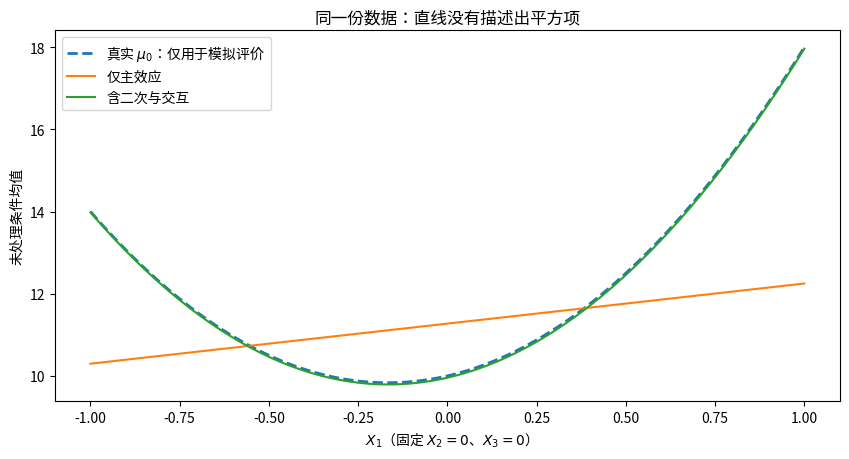

In [6]:
matrices = {spec: covariate_matrix(design, spec) for spec in ("main", "rich")}
scores, outcome_predictions, outcome_coefficients = {}, {}, {}
diagnostic_rows = []
for spec, A in matrices.items():
    ps_fit = fit_logistic(A, t)
    scores[spec] = np.asarray(ps_fit.predict(A))
    outcome_predictions[spec], outcome_coefficients[spec] = fit_outcomes(A, t, y)
    p = scores[spec]
    w_actual = np.where(t == 1, 1/p, 1/(1-p))
    diagnostic_rows.append({"特征": spec, "评分最小值": p.min(), "评分最大值": p.max(),
                            "实际最大权重": w_actual.max(), "处理人数": int(t.sum()),
                            "对照人数": int((1-t).sum())})
display(pd.DataFrame(diagnostic_rows).set_index("特征").round(4))

x_grid = np.linspace(-1, 1, 201)
slice_data = pd.DataFrame({"X1": x_grid, "X2": np.zeros(len(x_grid)),
                           "X3": np.zeros(len(x_grid))})
fig, ax = plt.subplots(figsize=(8.6, 4.7))
ax.plot(x_grid, 10+2*x_grid+6*x_grid**2, linestyle="--", linewidth=2,
        label=r"真实 $\mu_0$：仅用于模拟评价")
for spec, label in [("main", "仅主效应"), ("rich", "含二次与交互")]:
    prediction = covariate_matrix(slice_data, spec) @ outcome_coefficients[spec][0]
    ax.plot(x_grid, prediction, label=label)
ax.set(xlabel=r"$X_1$（固定 $X_2=0$、$X_3=0$）", ylabel="未处理条件均值",
       title="同一份数据：直线没有描述出平方项")
ax.legend()
fig.tight_layout()
plt.show()

### 4. 四种组合，分别由哪一项纠偏？

按原书的顺序组织四种设定：两类都对、仅结果对、仅评分对、两类都错。这里“对”指工作模型的形式正确，拟合值仍有抽样误差。

普通 OLS 的组内残差均值接近零，但加上不同的逆概率权重后，残差均值不一定仍为零。因此，AIPW 不会仅因为用了带截距的 OLS，就自动退化成结果回归。

,结果预测差,处理侧纠偏,减去对照侧纠偏,AIPW
设定,,,,
A 两类都对,2.4475,0.0044,-0.0006,2.4512
B 仅结果对,2.4475,0.0019,-0.0011,2.4482
C 仅评分对,3.9011,-0.6976,-0.7392,2.4642
D 两类都错,3.9011,0.0405,-0.0383,3.9033


,X1,X2,X3,T,预测差,处理侧纠偏,对照侧纠偏（待减）,AIPW得分
0,0.5479,0.6584,0,0,5.0783,-0.0000,6.0367,-0.9583
1,-0.1222,0.1882,0,0,3.5956,-0.0000,-3.1655,6.7611
2,0.7172,-0.5103,1,1,4.7812,-1.0447,0.0000,3.7364
3,0.3947,0.4914,0,0,4.6768,-0.0000,0.3383,4.3385
4,-0.8116,-0.8310,0,1,1.5076,4.1880,0.0000,5.6956
5,0.9512,0.5488,0,1,5.5581,4.2921,0.0000,9.8503


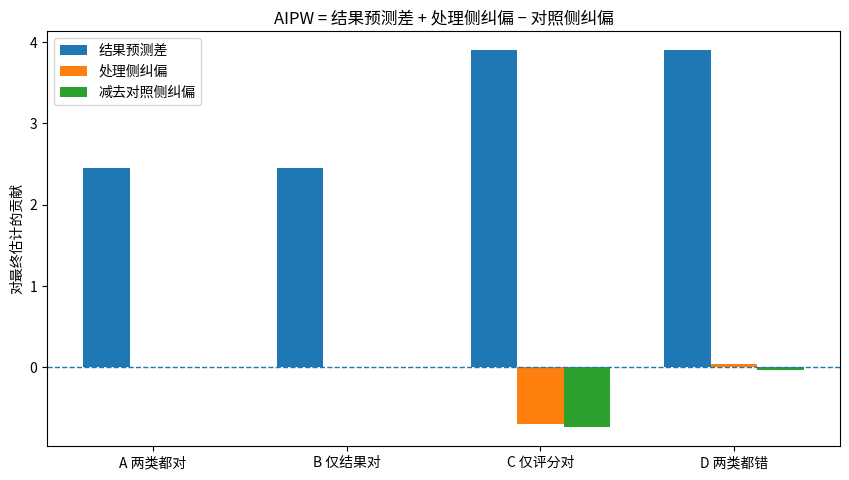

In [7]:
CASES = [("A 两类都对", "rich", "rich"),
         ("B 仅结果对", "main", "rich"),
         ("C 仅评分对", "rich", "main"),
         ("D 两类都错", "main", "main")]
METHODS = ["结果回归", "HT", "Hájek", "AIPW"]
case_terms, decomposition_rows = {}, []
for label, ps_spec, out_spec in CASES:
    m = outcome_predictions[out_spec]
    terms = aipw_components(t, y, scores[ps_spec], m[0], m[1])
    case_terms[label] = terms
    avg = terms.mean(axis=0)
    decomposition_rows.append({"设定": label, "结果预测差": avg[0],
                                "处理侧纠偏": avg[1], "减去对照侧纠偏": -avg[2],
                                "AIPW": avg[3]})
decomposition = pd.DataFrame(decomposition_rows).set_index("设定")
display(decomposition.round(4))

# 逐行展示“仅评分对”时，较差的结果预测怎样进入残差纠偏。
trace = design.head(6).copy()
for j, column in enumerate(["预测差", "处理侧纠偏", "对照侧纠偏（待减）", "AIPW得分"]):
    trace[column] = case_terms[CASES[2][0]][:6, j]
display(trace.round(4))

fig, ax = plt.subplots(figsize=(8.6, 4.9))
positions, width = np.arange(len(CASES)), 0.24
for j, column in enumerate(["结果预测差", "处理侧纠偏", "减去对照侧纠偏"]):
    ax.bar(positions+(j-1)*width, decomposition[column], width=width, label=column)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(positions, decomposition.index)
ax.set(ylabel="对最终估计的贡献", title="AIPW = 结果预测差 + 处理侧纠偏 − 对照侧纠偏")
ax.legend()
fig.tight_layout()
plt.show()

### 5. 和结果回归、HT、Hájek 放在一起比较

同一套评分只拟合一次，同一套结果模型也只拟合一次，再组合成四种设定。这样，换评分不会偷偷改变结果回归，换结果模型也不会改变 IPW。

下面还保留“结果回归与 Hájek 各占一半”作为对照。它不是双重稳健估计，只用来检查“把两个答案平均就行”的想法。

In [8]:
def all_estimates(A_main, A_rich, treatment, outcome):
    """同一份数据计算四种设定；同一辅助模型只拟合一次。"""
    z, y = np.asarray(treatment), np.asarray(outcome, dtype=float)
    matrices = {'main': A_main, 'rich': A_rich}
    probabilities, predictions = {}, {}
    for spec, A in matrices.items():
        fit = fit_logistic(A, z)
        probabilities[spec] = np.asarray(fit.predict(A))
        predictions[spec], _ = fit_outcomes(A, z, y)
    estimates = np.empty((len(CASES), len(METHODS)))
    for k, (_, ps_spec, out_spec) in enumerate(CASES):
        p, m = probabilities[ps_spec], predictions[out_spec]
        terms = aipw_components(z, y, p, m[0], m[1])
        w1, w0 = z/p, (1-z)/(1-p)
        estimates[k] = [terms[:, 0].mean(),
                        np.mean(w1*y-w0*y),
                        np.dot(w1, y)/w1.sum()-np.dot(w0, y)/w0.sum(),
                        terms[:, 3].mean()]
    return estimates


point_estimates = all_estimates(matrices["main"], matrices["rich"], t, y)
point_table = pd.DataFrame(point_estimates, index=[c[0] for c in CASES], columns=METHODS)
point_table["回归与Hájek各占一半"] = (point_table["结果回归"]+point_table["Hájek"])/2
point_table["总体ATE（评价）"] = truth["population_ate"]
display(point_table.round(4))
np.testing.assert_allclose(point_table["AIPW"], decomposition["AIPW"], atol=1e-10)
print(f"原始两组均值差：{y[t == 1].mean()-y[t == 0].mean():.4f}")

,结果回归,HT,Hájek,AIPW,回归与Hájek各占一半,总体ATE（评价）
A 两类都对,2.4475,2.2854,2.4359,2.4512,2.4417,2.4
B 仅结果对,2.4475,3.9144,3.8323,2.4482,3.1399,2.4
C 仅评分对,3.9011,2.2854,2.4359,2.4642,3.1685,2.4
D 两类都错,3.9011,3.9144,3.8323,3.9033,3.8667,2.4


原始两组均值差：4.4944


默认数据中，结果模型只放主效应时，回归估计约为 3.901；搭配完整评分后，AIPW 变为约 2.464。结果模型完整而评分遗漏非线性项时，Hájek 约为 3.832，AIPW 仍约为 2.448。全体真值是 2.4。

两类都错时，AIPW 仍在 3.9 附近。这里的纠偏并没有消除主要偏差。前三种设定在一次数据中接近真值，与“每次一定更准”不是一回事，后面要重新生成数据比较。

### 6. Bootstrap：两类模型都要重拟合

按原书第 12.3.1 节，整行重抽 $(X_i,T_i,Y_i)$，在每份 Bootstrap 数据中重新拟合评分、两组结果模型，再计算四种估计。预测也在这份重抽样的人群上平均，不能只重抽已经算好的 AIPW 得分。[1，第 12.1.2、12.3.1 节，附录 A.6]

$$
\widehat{\mathrm{SE}}_{\mathrm{boot}}
=\operatorname{SD}(\widehat\tau_1^*,\ldots,\widehat\tau_B^*),\qquad
\widehat\tau\pm z_{0.975}\widehat{\mathrm{SE}}_{\mathrm{boot}}.
$$

使用事先固定的低维模型和未截断评分。这里是正则条件下的近似区间，不是随机化得到的精确区间，也没有宣称 Bootstrap 能补救模型偏差。

估计  Bootstrap_SE   95%下限   95%上限
设定     方法                                         
A 两类都对 结果回归   2.4475        0.0412  2.3667  2.5282
       HT     2.2854        0.2385  1.8180  2.7528
       Hájek  2.4359        0.0866  2.2662  2.6055
       AIPW   2.4512        0.0429  2.3671  2.5354
B 仅结果对 结果回归   2.4475        0.0412  2.3667  2.5282
       HT     3.9144        0.1395  3.6409  4.1879
       Hájek  3.8323        0.0856  3.6645  4.0002
       AIPW   2.4482        0.0415  2.3669  2.5296
C 仅评分对 结果回归   3.9011        0.0888  3.7270  4.0751
       HT     2.2854        0.2385  1.8180  2.7528
       Hájek  2.4359        0.0866  2.2662  2.6055
       AIPW   2.4642        0.0735  2.3203  2.6082
D 两类都错 结果回归   3.9011        0.0888  3.7270  4.0751
       HT     3.9144        0.1395  3.6409  4.1879
       Hájek  3.8323        0.0856  3.6645  4.0002
       AIPW   3.9033        0.0904  3.7261  4.0805

完成 999 次整行重抽样；每次重新拟合全部工作模型。


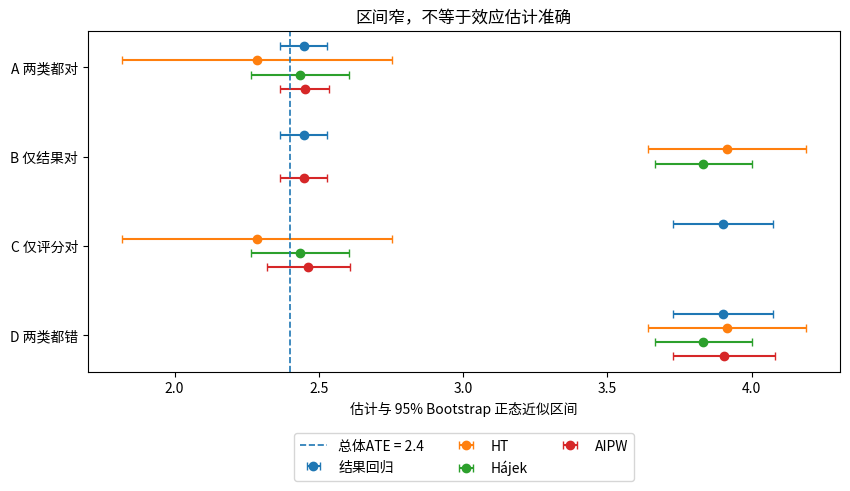

In [9]:
def bootstrap_all(A_main, A_rich, treatment, outcome, n_boot: int, seed: int):
    """整行重抽样；每次重新拟合评分和两组结果模型，不跳过失败。"""
    if isinstance(n_boot, bool) or not isinstance(n_boot, (int, np.integer)) or n_boot < 2:
        raise ValueError('n_boot 必须是至少为 2 的整数。')
    z, y = np.asarray(treatment), np.asarray(outcome)
    rng = np.random.default_rng(seed)
    results = np.empty((n_boot, len(CASES), len(METHODS)))
    for b in range(n_boot):
        idx = rng.integers(0, len(z), size=len(z))
        results[b] = all_estimates(A_main[idx], A_rich[idx], z[idx], y[idx])
    return results


boot = bootstrap_all(matrices["main"], matrices["rich"], t, y, N_BOOT, SEED_BOOT)
boot_se = boot.std(axis=0, ddof=1)
interval_rows = []
for k, (label, _, _) in enumerate(CASES):
    for j, method in enumerate(METHODS):
        value, se = point_estimates[k, j], boot_se[k, j]
        interval_rows.append({"设定": label, "方法": method, "估计": value,
                              "Bootstrap_SE": se, "95%下限": value-Z_CRIT*se,
                              "95%上限": value+Z_CRIT*se})
interval_table = pd.DataFrame(interval_rows).set_index(["设定", "方法"])
display(interval_table.round(4))
print(f"完成 {len(boot)} 次整行重抽样；每次重新拟合全部工作模型。")

fig, ax = plt.subplots(figsize=(8.6, 5.1))
positions = np.arange(len(CASES))
for j, method in enumerate(METHODS):
    ax.errorbar(point_estimates[:, j], positions+(j-1.5)*0.16,
                xerr=Z_CRIT*boot_se[:, j], fmt="o", capsize=3, label=method)
ax.axvline(truth["population_ate"], linestyle="--", linewidth=1.2, label="总体ATE = 2.4")
ax.set_yticks(positions, [c[0] for c in CASES])
ax.invert_yaxis()
ax.set(xlabel="估计与 95% Bootstrap 正态近似区间", title="区间窄，不等于效应估计准确")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3)
fig.tight_layout()
plt.show()

默认数据下，前三种设定的 AIPW 区间都包含 2.4。两类都错时，区间约为 [3.726, 4.081]，并没有覆盖它。两类都对时，AIPW 的 Bootstrap 标准误约为 0.043；只有评分对时约为 0.073。纠偏可以消除模型偏差，却不一定把两种情况的波动也变成一样。

## 重复模拟：一次接近真值，够不够？

### 1. 每次重新生成研究对象

对 600 人和 2,400 人两种规模，各生成 400 份独立数据。每份数据都完整拟合四种设定，各种方法使用相同的研究对象。

记录的是相对于总体 ATE 2.4 的误差。不会每次拿样本潜在结局平均差作目标，也不会把主案例里拟合好的模型重复用于后面的研究。

In [10]:
rng_repeat = np.random.default_rng(SEED_REPEAT)
repeated = {}
for n in SAMPLE_SIZES:
    values = np.empty((N_REPEATS, len(CASES), len(METHODS)))
    for r in range(N_REPEATS):
        d_r, y_r, _ = make_observational_data(n, int(rng_repeat.integers(0, 2**31)))
        values[r] = all_estimates(covariate_matrix(d_r, "main"),
                                  covariate_matrix(d_r, "rich"), d_r["T"].to_numpy(), y_r)
    repeated[n] = values
print(f"完成 {len(SAMPLE_SIZES)} 种样本量，每种 {N_REPEATS} 次；没有跳过失败的数据。")

完成 2 种样本量，每种 400 次；没有跳过失败的数据。


### 2. 分开看偏差、波动和 RMSE

偏差取重复估计的均值减真值；经验标准差描述数据之间的波动；均方根误差（RMSE）同时包含两者。偏差的 Monte Carlo 标准误为经验标准差除以 $\sqrt{R}$，其中 $R$ 是重复次数。

图上的误差棒表示“平均偏差”的模拟不确定性，不是某一次因果效应估计的置信区间。原书第 12.3.2 节同样通过重复生成数据比较偏差和标准误；本篇另列 RMSE 与 Monte Carlo 误差。

平均偏差    经验SD    RMSE  偏差MC_SE
n    设定     方法                                    
600  A 两类都对 结果回归  -0.0043  0.0940  0.0940   0.0047
            HT     0.0055  0.4301  0.4296   0.0215
            Hájek -0.0050  0.1723  0.1722   0.0086
            AIPW  -0.0043  0.0961  0.0961   0.0048
     B 仅结果对 结果回归  -0.0043  0.0940  0.0940   0.0047
            HT     1.2562  0.2855  1.2881   0.0143
            Hájek  1.2042  0.1920  1.2194   0.0096
            AIPW  -0.0046  0.0946  0.0946   0.0047
     C 仅评分对 结果回归   1.2731  0.1982  1.2884   0.0099
            HT     0.0055  0.4301  0.4296   0.0215
            Hájek -0.0050  0.1723  0.1722   0.0086
            AIPW  -0.0000  0.1528  0.1526   0.0076
     D 两类都错 结果回归   1.2731  0.1982  1.2884   0.0099
            HT     1.2562  0.2855  1.2881   0.0143
            Hájek  1.2042  0.1920  1.2194   0.0096
            AIPW   1.2721  0.2024  1.2881   0.0101
2400 A 两类都对 结果回归   0.0009  0.0447  0.0447   0.0022
            HT     0.0130  0.1909  0.1911   0.0095
            Hájek  0.0048  0.0742  0.0742   0.0037
            AIPW   0.0011  0.0455  0.0455   0.0023
     B 仅结果对 结果回归   0.0009  0.0447  0.0447   0.0022
            HT     1.2661  0.1346  1.2732   0.0067
            Hájek  1.2244  0.0904  1.2277   0.0045
            AIPW   0.0007  0.0449  0.0449   0.0022
     C 仅评分对 结果回归   1.2920  0.0931  1.2953   0.0047
            HT     0.0130  0.1909  0.1911   0.0095
            Hájek  0.0048  0.0742  0.0742   0.0037
            AIPW   0.0050  0.0661  0.0662   0.0033
     D 两类都错 结果回归   1.2920  0.0931  1.2953   0.0047
            HT     1.2661  0.1346  1.2732   0.0067
            Hájek  1.2244  0.0904  1.2277   0.0045
            AIPW   1.2890  0.0940  1.2924   0.0047

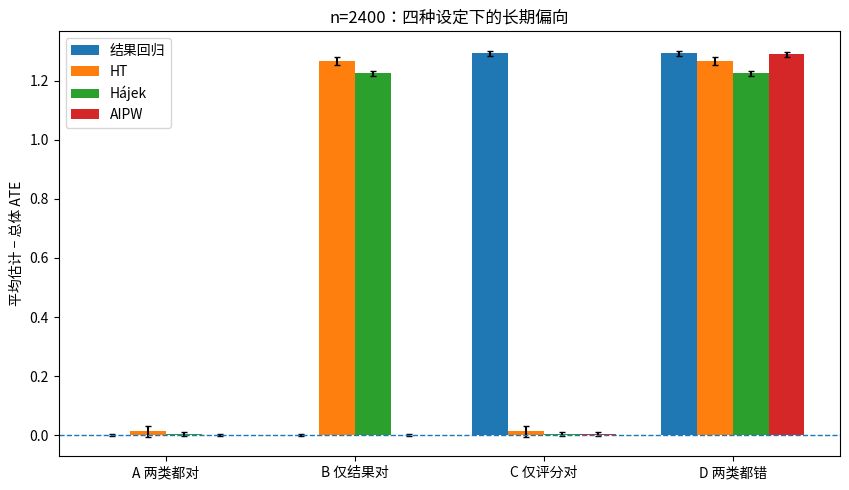

In [11]:
summary_rows = []
for n, values in repeated.items():
    for k, (label, _, _) in enumerate(CASES):
        for j, method in enumerate(METHODS):
            estimates = values[:, k, j]
            errors = estimates-truth["population_ate"]
            sd = estimates.std(ddof=1)
            summary_rows.append({"n": n, "设定": label, "方法": method,
                                 "平均偏差": errors.mean(), "经验SD": sd,
                                 "RMSE": np.sqrt(np.mean(errors**2)),
                                 "偏差MC_SE": sd/np.sqrt(len(estimates))})
repeat_summary = pd.DataFrame(summary_rows).set_index(["n", "设定", "方法"])
display(repeat_summary.round(4))

fig, ax = plt.subplots(figsize=(8.6, 5.0))
positions, width = np.arange(len(CASES)), 0.19
for j, method in enumerate(METHODS):
    rows = repeat_summary.xs((SAMPLE_SIZES[-1], method), level=("n", "方法"))
    ax.bar(positions+(j-1.5)*width, rows["平均偏差"], width=width,
           yerr=Z_CRIT*rows["偏差MC_SE"], capsize=2, label=method)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(positions, [c[0] for c in CASES])
ax.set(ylabel="平均估计 − 总体 ATE", title=f"n={SAMPLE_SIZES[-1]}：四种设定下的长期偏向")
ax.legend()
fig.tight_layout()
plt.show()

### 3. 只盯着 AIPW，看增加样本量有没有解决问题

这次重复结果中，两类都对时，AIPW 的经验标准差从约 0.096 降到 0.046；只有评分对时，从约 0.153 降到 0.066。两类都错时，标准差也从约 0.202 降到 0.094，但平均偏差仍约为 1.27–1.29。分布变窄了，却没有向真值靠近。

前三种设定有一致性保证，但有限样本中的波动仍然不同；结果模型正确时，单纯回归也可能比 AIPW 更稳定。双重稳健没有给出“方差一定最小”或“总比其他方法好”的保证。[1，第 12.3.2、12.4 节]

两类都错时，增加样本量只能更精确地估计一个可能有偏的数。下面把 AIPW 的重复误差直接画出来，不只比较单个点估计。

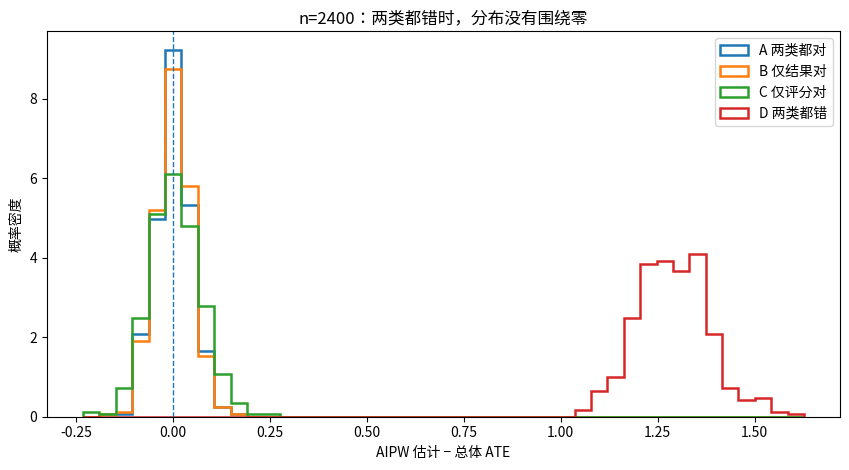

In [12]:
fig, ax = plt.subplots(figsize=(8.6, 4.8))
errors = repeated[SAMPLE_SIZES[-1]][:, :, METHODS.index("AIPW")]-truth["population_ate"]
bins = np.linspace(errors.min()-0.03, errors.max()+0.03, 45)
for k, (label, _, _) in enumerate(CASES):
    ax.hist(errors[:, k], bins=bins, density=True, histtype="step", linewidth=1.8, label=label)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set(xlabel="AIPW 估计 − 总体 ATE", ylabel="概率密度",
       title=f"n={SAMPLE_SIZES[-1]}：两类都错时，分布没有围绕零")
ax.legend()
fig.tight_layout()
plt.show()

## 区间检查：点估计稳健，不等于误差范围自动正确

### 1. 每份新数据，都重新构造区间

继续沿用原书的 Bootstrap 方差估计，但这次在 120 份独立的 800 人数据上完整重复。每份数据做 149 次整行 Bootstrap，重新拟合两类模型，然后检查 AIPW 区间是否覆盖同一个总体 ATE 2.4。

这是一项小规模的区间实验。149 次 Bootstrap 的标准误本身还有数值波动；120 次研究得到的覆盖率也有 Monte Carlo 误差，不能把 0.93 与 0.95 的差直接解释成方法失效。代码同时报告覆盖率的 Monte Carlo 标准误。

本篇没有使用“把逐人 AIPW 得分当成现成独立观测，直接算标准误”的捷径。第二本书第 9.3 节的得分方差公式与交叉拟合及辅助估计质量条件配套，不能仅凭双重稳健一致性就不加条件地套用到所有错设情况。[1，第 12.3.1 节；2，第 9.3 节、定理 9.3.1]

In [13]:
rng_coverage = np.random.default_rng(SEED_COVERAGE)
coverage_records = []
for r in range(N_COVERAGE):
    seed_data, seed_boot = [int(v) for v in rng_coverage.integers(0, 2**31, size=2)]
    d_c, y_c, _ = make_observational_data(N_COVERAGE_SAMPLE, seed_data)
    a_c, b_c = covariate_matrix(d_c, "main"), covariate_matrix(d_c, "rich")
    t_c = d_c["T"].to_numpy()
    theta_c = all_estimates(a_c, b_c, t_c, y_c)[:, -1]
    draws_c = bootstrap_all(a_c, b_c, t_c, y_c, N_BOOT_COVERAGE, seed_boot)
    se_c = draws_c[:, :, -1].std(axis=0, ddof=1)
    for k, (label, _, _) in enumerate(CASES):
        lower, upper = theta_c[k]-Z_CRIT*se_c[k], theta_c[k]+Z_CRIT*se_c[k]
        coverage_records.append({"重复": r, "设定": label, "估计": theta_c[k],
                                  "Bootstrap_SE": se_c[k], "区间宽度": upper-lower,
                                  "覆盖": lower <= 2.4 <= upper})
coverage_results = pd.DataFrame(coverage_records)
print(f"完成 {N_COVERAGE} 份独立研究，每份 {N_BOOT_COVERAGE} 次完整 Bootstrap。")

完成 120 份独立研究，每份 149 次完整 Bootstrap。


### 2. 覆盖率和区间宽度一起看

若覆盖率为 $\widehat c$，它的模拟标准误近似为 $\sqrt{\widehat c(1-\widehat c)/R}$。表中同时列出重复点估计的经验标准差与平均 Bootstrap 标准误；两者回答的是不同层次的重复性问题。

两类模型都错时，区间即使正确描述了估计量的抽样波动，也可能很少覆盖真正的 ATE。Bootstrap 会重复已有的统计程序，不会自动找回被模型漏掉的关系。

,覆盖次数,覆盖率,覆盖率MC_SE,平均区间宽度,点估计经验SD,平均Bootstrap_SE
设定,,,,,,
A 两类都对,117,0.9750,0.0143,0.3228,0.0759,0.0823
B 仅结果对,112,0.9333,0.0228,0.3154,0.0731,0.0804
C 仅评分对,116,0.9667,0.0164,0.4803,0.1144,0.1225
D 两类都错,0,0.0000,0.0000,0.6824,0.1715,0.1741


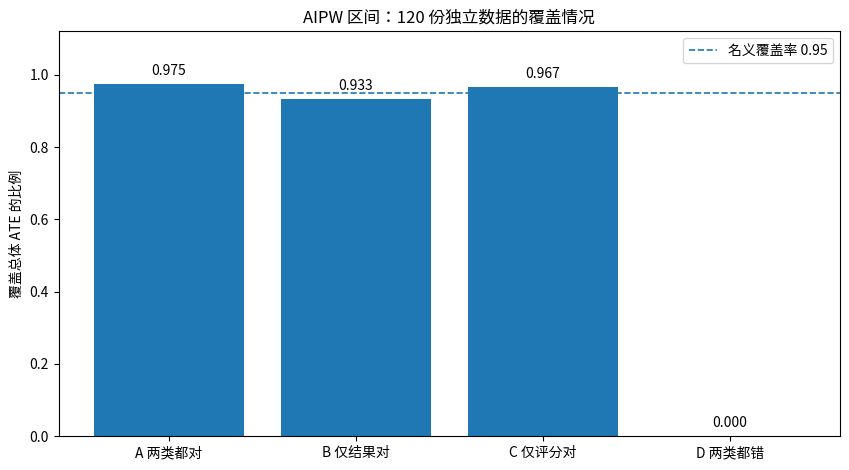

In [14]:
coverage_rows = []
for label, _, _ in CASES:
    group = coverage_results.loc[coverage_results["设定"] == label]
    c = group["覆盖"].mean()
    coverage_rows.append({"设定": label, "覆盖次数": int(group["覆盖"].sum()), "覆盖率": c,
                          "覆盖率MC_SE": np.sqrt(c*(1-c)/len(group)),
                          "平均区间宽度": group["区间宽度"].mean(),
                          "点估计经验SD": group["估计"].std(ddof=1),
                          "平均Bootstrap_SE": group["Bootstrap_SE"].mean()})
coverage_table = pd.DataFrame(coverage_rows).set_index("设定")
display(coverage_table.round(4))

fig, ax = plt.subplots(figsize=(8.6, 4.8))
ax.bar(np.arange(len(CASES)), coverage_table["覆盖率"])
ax.axhline(0.95, linestyle="--", linewidth=1.2, label="名义覆盖率 0.95")
for k, value in enumerate(coverage_table["覆盖率"]):
    ax.text(k, value+0.025, f"{value:.3f}", ha="center")
ax.set_xticks(np.arange(len(CASES)), coverage_table.index)
ax.set(ylabel="覆盖总体 ATE 的比例", ylim=(0, 1.12),
       title=f"AIPW 区间：{N_COVERAGE} 份独立数据的覆盖情况")
ax.legend()
fig.tight_layout()
plt.show()

默认运行中，前三种设定分别有 117、112、116 个区间覆盖 2.4，对应覆盖率 0.975、0.933、0.967；两类都错时为 0/120。这不足以把前三者排成可靠性的名次，但能看到明显的模型错设偏差并未被区间计算消除。

表里的 Monte Carlo 标准误使用覆盖率的代入估计。0/120 时公式给出 0，这是边界处的代入结果，不代表覆盖概率被精确确定为零，也不代表重复实验没有不确定性。

## 进一步分析：两处错误怎样一起起作用？

### 1. 用三种人的总体表，直接算期望

前面的模型都是从有限样本估计的。现在暂时去掉抽样噪声，用一个三层总体检查偏差分解。

记采用工作函数 $q,m_0,m_1$ 的 AIPW 总体表达为 $\Psi(q,m_0,m_1)$。将前面的两侧偏差相减，得到：

$$
\Psi(q,m_0,m_1)-\tau
=E\left[(e-q)\left\{\frac{\mu_1-m_1}{q}
+\frac{\mu_0-m_0}{1-q}\right\}\right].
$$

这是由定理 12.1 的证明整理出的 ATE 形式。下面另外指定偏移方向，令 $q=e+a h$、$m_t=\mu_t+b d_t$。$a$ 控制评分偏差，$b$ 控制结果偏差；它们不是从数据估计的参数，也不是对未测混杂的敏感性分析。

如果 $a=0$ 或 $b=0$，总体偏差为零；其他位置则要看两类误差的方向与分母，不能只说“两边误差相乘就变小”。[1，第 12.4 节]

,比例,e,mu0,mu1
层,,,,
低,0.25,0.2,8.0,9.0
中,0.50,0.5,12.0,14.0
高,0.25,0.8,16.0,19.0


,总体偏差
两类都对,0.00000
仅评分对,0.00000
仅结果对,0.00000
两类都有偏移,0.42992


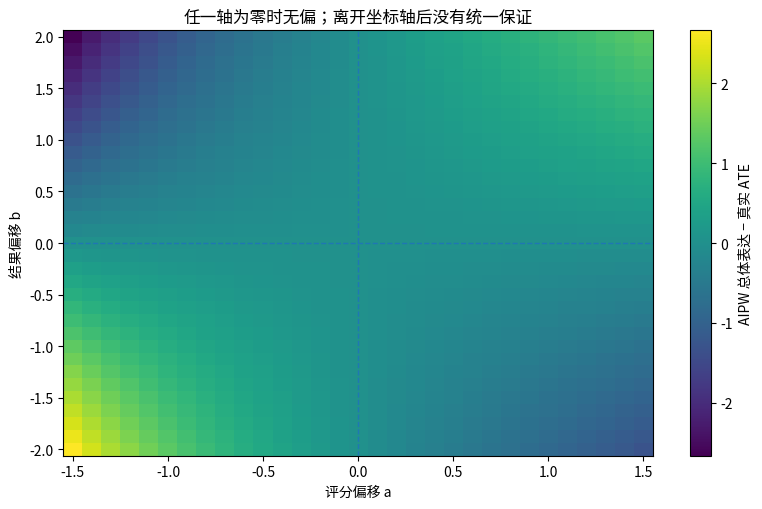

In [15]:
pop = pd.DataFrame({"比例": [0.25, 0.50, 0.25], "e": [0.20, 0.50, 0.80],
                    "mu0": [8., 12., 16.], "mu1": [9., 14., 19.]},
                   index=pd.Index(["低", "中", "高"], name="层"))
display(pop)
pi, e_pop, mu0_pop, mu1_pop = (pop[name].to_numpy() for name in ("比例", "e", "mu0", "mu1"))
tau_pop = np.dot(pi, mu1_pop-mu0_pop)
h = np.array([0.08, -0.03, 0.04])
d0, d1 = np.array([2., -1., 3.]), np.array([3., 1., -2.])

def population_bias(a, b):
    q, m0, m1 = e_pop+a*h, mu0_pop+b*d0, mu1_pop+b*d1
    if np.any((q <= 0) | (q >= 1)):
        raise ValueError("这个偏移让评分越过 0 或 1。")
    # 先按两种 T 取条件期望，再按层比例加权；不是只调用偏差公式。
    expected_score = m1-m0+e_pop*(mu1_pop-m1)/q-(1-e_pop)*(mu0_pop-m0)/(1-q)
    bias_direct = np.dot(pi, expected_score)-tau_pop
    bias_product = np.dot(pi, (e_pop-q)*((mu1_pop-m1)/q+(mu0_pop-m0)/(1-q)))
    np.testing.assert_allclose(bias_direct, bias_product, atol=1e-12)
    return float(bias_direct)

a_grid, b_grid = np.linspace(-1.5, 1.5, 31), np.linspace(-2, 2, 33)
bias_surface = np.array([[population_bias(a, b) for a in a_grid] for b in b_grid])
np.testing.assert_allclose(bias_surface[:, 15], 0, atol=1e-12)
np.testing.assert_allclose(bias_surface[16, :], 0, atol=1e-12)
display(pd.Series({"两类都对": population_bias(0, 0),
                   "仅评分对": population_bias(0, 1),
                   "仅结果对": population_bias(1, 0),
                   "两类都有偏移": population_bias(1, 1)}, name="总体偏差").to_frame().round(5))

fig, ax = plt.subplots(figsize=(8.2, 5.2))
mesh = ax.pcolormesh(a_grid, b_grid, bias_surface, shading="nearest")
fig.colorbar(mesh, ax=ax, label="AIPW 总体表达 − 真实 ATE")
ax.axvline(0, linestyle="--", linewidth=1)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set(xlabel="评分偏移 a", ylabel="结果偏移 b", title="任一轴为零时无偏；离开坐标轴后没有统一保证")
fig.tight_layout()
plt.show()

### 2. 两个函数都知道，低重叠还会有影响吗？

沿用第六篇的一维生成模型：

$$
\begin{aligned}
X&\sim\operatorname{Uniform}(-2,2),\qquad e_\kappa(X)=\operatorname{expit}(\kappa X),\\
\mu_0(X)&=5+2X+X^2,\qquad \tau(X)=1+X^2,\\
Y&=\mu_0(X)+T\tau(X)+\varepsilon,\qquad\varepsilon\sim N(0,1).
\end{aligned}
$$

总体 ATE 是 $7/3$，不随 $\kappa$ 改变。这一次刻意把真实 $e,\mu_0,\mu_1$ 直接代入，叫作 oracle 计算，即知道辅助真值的理想对照。它不是实际可用的拟合程序，而是为了排除模型错设与估计误差，只观察低重叠的影响。

即使结果均值完全正确，个体观察结局仍有噪声；AIPW 加权的是这部分噪声，不会让它凭空消失。原书对双重稳健有限样本不稳定性的讨论见第 12.4 节，下面用这个另设模型把其中的分母作用分开算。

,平均偏差,经验SD,RMSE,最大残差纠偏绝对值的中位数
κ,,,,
0.5,-0.0030,0.0725,0.0725,9.3887
1.5,0.0005,0.0916,0.0915,32.2665
3.0,-0.0006,0.2362,0.2359,145.2859


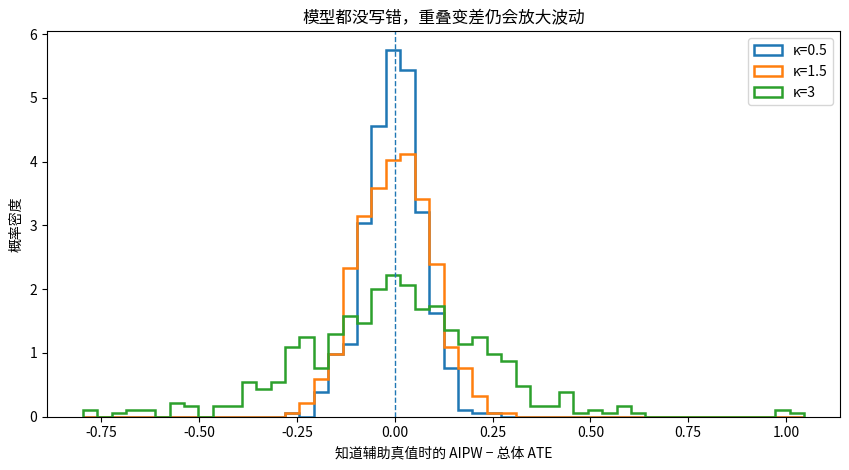

In [16]:
rng_overlap = np.random.default_rng(SEED_OVERLAP)
overlap_values, overlap_rows = {}, []
for strength in STRENGTHS:
    estimates = np.empty(N_OVERLAP_REPEATS)
    max_corrections = np.empty(N_OVERLAP_REPEATS)
    for r in range(N_OVERLAP_REPEATS):
        x_o = rng_overlap.uniform(-2, 2, N_OVERLAP)
        p_o = expit(strength*x_o)
        t_o = rng_overlap.binomial(1, p_o)
        m0_o, tau_o = 5+2*x_o+x_o**2, 1+x_o**2
        y_o = m0_o+t_o*tau_o+rng_overlap.normal(0, 1, N_OVERLAP)
        terms_o = aipw_components(t_o, y_o, p_o, m0_o, m0_o+tau_o)
        estimates[r] = terms_o[:, 3].mean()
        max_corrections[r] = np.abs(terms_o[:, 1]-terms_o[:, 2]).max()
    overlap_values[strength] = estimates
    overlap_rows.append({"κ": strength, "平均偏差": estimates.mean()-7/3,
                         "经验SD": estimates.std(ddof=1),
                         "RMSE": np.sqrt(np.mean((estimates-7/3)**2)),
                         "最大残差纠偏绝对值的中位数": np.median(max_corrections)})
overlap_summary = pd.DataFrame(overlap_rows).set_index("κ")
display(overlap_summary.round(4))

fig, ax = plt.subplots(figsize=(8.6, 4.8))
all_errors = np.concatenate([v-7/3 for v in overlap_values.values()])
bins = np.linspace(all_errors.min()-0.02, all_errors.max()+0.02, 51)
for strength, values in overlap_values.items():
    ax.hist(values-7/3, bins=bins, density=True, histtype="step", linewidth=1.8,
            label=f"κ={strength:g}")
ax.axvline(0, linestyle="--", linewidth=1)
ax.set(xlabel="知道辅助真值时的 AIPW − 总体 ATE", ylabel="概率密度",
       title="模型都没写错，重叠变差仍会放大波动")
ax.legend()
fig.tight_layout()
plt.show()

### 3. 把波动增加的原因算出来

辅助真值已知时，500 次模拟的经验标准差仍从约 0.073 增至 0.236。单份数据中最大残差纠偏绝对值的中位数，从约 9.4 增至 145.3。预测正确消除了系统性的均值误差，但分母仍能放大个体噪声。

在刚才的模型中，代入真函数后，逐人的得分为：

$$
\phi=\tau(X)+\varepsilon\left\{\frac{T}{e(X)}-\frac{1-T}{1-e(X)}\right\}.
$$

给定 $X$，纠偏项均值为零、条件方差为 $1/e(X)+1/[1-e(X)]$。由全方差公式：

$$
\operatorname{Var}(\phi)
=\operatorname{Var}\{\tau(X)\}+E\left[\frac1{e(X)}+\frac1{1-e(X)}\right]
=\frac{64}{45}+2+\frac{\sinh(2\kappa)}{\kappa},\qquad \kappa>0.
$$

因为 $X\sim\operatorname{Uniform}(-2,2)$，$\operatorname{Var}(X^2)=64/45$；最后一项来自对指数函数积分。独立同分布样本的平均得分方差再除以 $n$。这是针对本篇生成模型的直接推导，不是对所有拟合 AIPW 的通用标准误公式。

这里说明的是：即使辅助均值已知，残差的逆概率放大仍然存在。如果数据还含有模型错设或极端个体，表现可能更差。截断评分也不能无条件维持“只要评分正确”的保证——截断后的函数已经不再是真评分。下一道练习只改变残差归一化，不删人，也不截断评分。

,经验SD,按生成模型计算的理论SD
κ,,
0.5,0.07255,0.06936
1.5,0.09158,0.09175
3.0,0.23618,0.24266


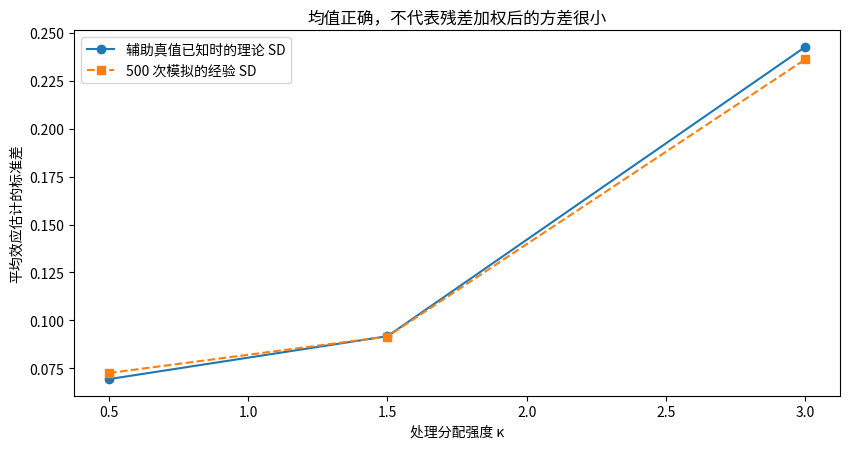

In [17]:
theory_sd = np.sqrt((64/45+2+np.sinh(2*np.array(STRENGTHS))/np.array(STRENGTHS))/N_OVERLAP)
oracle_comparison = overlap_summary[["经验SD"]].copy()
oracle_comparison["按生成模型计算的理论SD"] = theory_sd
display(oracle_comparison.round(5))

# 用独立的数值积分再核对理论表达，不使用模拟估计来定义真值。
nodes, weights = np.polynomial.legendre.leggauss(120)
x_int, mass = 2*nodes, weights/2
for strength, sd in zip(STRENGTHS, theory_sd):
    p_int = expit(strength*x_int)
    variance_integral = np.dot(mass, ((1+x_int**2)-7/3)**2+1/p_int+1/(1-p_int))
    np.testing.assert_allclose(variance_integral/N_OVERLAP, sd**2, rtol=1e-10)

fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.plot(STRENGTHS, theory_sd, marker="o", label="辅助真值已知时的理论 SD")
ax.plot(STRENGTHS, oracle_comparison["经验SD"], marker="s", linestyle="--",
        label=f"{N_OVERLAP_REPEATS} 次模拟的经验 SD")
ax.set(xlabel="处理分配强度 κ", ylabel="平均效应估计的标准差",
       title="均值正确，不代表残差加权后的方差很小")
ax.legend()
fig.tight_layout()
plt.show()

## 练习

### 1. 离散分层时，几种方法为什么会完全相同？

回到第六篇的三层表。每一层的评分直接取该层处理比例，两组结果模型直接取对应层内均值。按 Ding 练习 12.1，比较分层标准化、结果回归、HT、Hájek 和 AIPW。[1，第 12.5 节]

先判断：这些值相同，是不是说明五种方法在一般数据中都等价？

参考实现如下。为核对逐人代码，按汇总表展开观察数据；层内加入均值为零的变化，避免所有人的残差都恰好为零。这些变化不改变汇总均值。

In [18]:
saturated = pd.DataFrame({"层": [0, 1, 2], "n": [100, 200, 100],
                           "n1": [20, 100, 80], "Y均值1": [11., 15., 19.],
                           "Y均值0": [10., 12., 14.]})
saturated["n0"] = saturated["n"]-saturated["n1"]
expanded = []
for _, row in saturated.iterrows():
    for group in (0, 1):
        count = int(row[f"n{group}"])
        values = row[f"Y均值{group}"]+np.linspace(-1, 1, count)
        expanded.append(pd.DataFrame({"层": int(row["层"]), "T": group, "Y": values}))
disc = pd.concat(expanded, ignore_index=True)
stratum = disc["层"].to_numpy()
z_s, y_s = disc["T"].to_numpy(), disc["Y"].to_numpy()
p_s = (saturated["n1"]/saturated["n"]).to_numpy()[stratum]
m0_s, m1_s = (saturated[f"Y均值{g}"].to_numpy()[stratum] for g in (0, 1))
w1_s, w0_s = z_s/p_s, (1-z_s)/(1-p_s)
terms_s = aipw_components(z_s, y_s, p_s, m0_s, m1_s)
values_s = pd.Series({
    "分层标准化": np.average(saturated["Y均值1"]-saturated["Y均值0"], weights=saturated["n"]),
    "结果回归": np.mean(m1_s-m0_s), "HT": np.mean(w1_s*y_s-w0_s*y_s),
    "Hájek": np.dot(w1_s, y_s)/w1_s.sum()-np.dot(w0_s, y_s)/w0_s.sum(),
    "AIPW": terms_s[:, 3].mean(),
}, name="估计")
display(values_s.to_frame().round(8))
np.testing.assert_allclose(values_s, values_s.iloc[0], atol=1e-12)
np.testing.assert_allclose(terms_s[:, 1:3].mean(axis=0), 0, atol=1e-12)
print("核对通过：每层两组都存在、使用层内比例与均值时，五种计算相同。")

,估计
分层标准化,3.0
结果回归,3.0
HT,3.0
Hájek,3.0
AIPW,3.0


核对通过：每层两组都存在、使用层内比例与均值时，五种计算相同。


相同来自这次的离散饱和设定：每层两组都存在，评分正好等于该层处理比例，结果预测正好等于层内均值。加权后各层比例一致，层内残差求和为零。这不代表连续变量上的错设回归、一般评分模型与匹配都能得到同样结果。

### 2. 把残差权重归一化，还是双重稳健吗？

Ding 练习 12.2 给出另一种增广形式：[1，第 12.5 节]

$$
\widehat M_{1,N}^{\mathrm{DR}}
=\frac1n\sum_i\widehat\mu_{1i}
+\frac{\sum_i T_i(Y_i-\widehat\mu_{1i})/\widehat e_i}{\sum_i T_i/\widehat e_i},
$$

$$
\widehat M_{0,N}^{\mathrm{DR}}
=\frac1n\sum_i\widehat\mu_{0i}
+\frac{\sum_i (1-T_i)(Y_i-\widehat\mu_{0i})/(1-\widehat e_i)}{\sum_i (1-T_i)/(1-\widehat e_i)}.
$$

两者相减为归一化残差版本。总体中，评分正确使两个归一化分母都为 1；结果正确则使相应残差分子为零。因此，在相应收敛与矩条件下，它也具有双重稳健一致性。但有限样本里，它不必与本篇主式相同，不能悄悄替换后仍声称计算了完全同一个数。

请用主案例的四种设定比较两式，再把观察结局与两种结果预测同时增加 100，检查处理效应是否改变。

In [19]:
def normalized_aipw(treatment, outcome, propensity, mu0, mu1):
    terms = aipw_components(treatment, outcome, propensity, mu0, mu1)
    z, p = np.asarray(treatment), np.asarray(propensity)
    mass1, mass0 = np.sum(z/p), np.sum((1-z)/(1-p))
    if mass1 <= 0 or mass0 <= 0:
        raise ValueError("归一化版本要求两组都存在。")
    return float(terms[:, 0].mean()+terms[:, 1].sum()/mass1-terms[:, 2].sum()/mass0)

normalization_rows = []
for label, ps_spec, out_spec in CASES:
    p, m = scores[ps_spec], outcome_predictions[out_spec]
    basic = aipw_components(t, y, p, m[0], m[1])[:, 3].mean()
    normalized = normalized_aipw(t, y, p, m[0], m[1])
    shifted = aipw_components(t, y+100, p, m[0]+100, m[1]+100)[:, 3].mean()
    shifted_normalized = normalized_aipw(t, y+100, p, m[0]+100, m[1]+100)
    np.testing.assert_allclose([shifted, shifted_normalized], [basic, normalized], atol=1e-10)
    normalization_rows.append({"设定": label, "AIPW主式": basic,
                               "归一化残差版本": normalized, "二者之差": normalized-basic,
                               "共同平移后的主式": shifted})
display(pd.DataFrame(normalization_rows).set_index("设定").round(6))
print("共同改变结局与两种预测的计分起点，两个版本的效应都不变。")

,AIPW主式,归一化残差版本,二者之差,共同平移后的主式
设定,,,,
A 两类都对,2.451239,2.451269,0.000030,2.451239
B 仅结果对,2.448239,2.448230,-0.000009,2.448239
C 仅评分对,2.464245,2.462703,-0.001542,2.464245
D 两类都错,3.903293,3.903061,-0.000232,3.903293


共同改变结局与两种预测的计分起点，两个版本的效应都不变。


## 小结

AIPW 在结果预测差上加两侧的加权残差纠偏。评分正确，或者两组结果模型都正确时，在相应条件下可以一致估计 ATE；它不是结果回归与 IPW 的平均，也不是自动挑选两者中更好的那个。

主模拟中，遗漏非线性项带来的偏差，能由正确的另一类模型消除；两类都错时则没有这项保证。低重叠实验进一步说明，即使辅助函数已知，残差仍会被逆概率权重放大。点估计、方差、识别条件要分别检查。

本篇使用固定的低维模型与整行重拟合 Bootstrap。换成灵活机器学习模型后，还要处理过拟合、正交化与交叉拟合；这些内容将在后续 DML 笔记展开。下一篇先讨论另一类问题：有重要混杂变量没有被观察到时，结论对这些遗漏有多敏感。

## 参考资料与本篇改写范围

[1] Peng Ding. *A First Course in Causal Inference*. 上传文件《因果推断.pdf》，arXiv:2305.18793v2，2023-10-03。第 12.1 节用于 AIPW 的总体与样本形式、双重稳健定理及偏差分解；第 12.2 节用于从 IPW 降噪与结果回归纠偏两个角度解释；第 12.3 节用于四种模型设定、估计流程和整行 Bootstrap；第 12.4 节用于两类模型均错时的限制；练习 12.1–12.2 用于离散饱和设定与归一化残差版本。正文页 169–178，对应该附件 PDF 页 195–204。Bootstrap 正态近似区间另参考附录 A.6。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 上传文件《CausalML_book_2022.pdf》，扉页版本 0.1.2，2026-05-03。第 9.3 节在交互回归模型中写出同一 ATE 得分，并将正交性、交叉拟合及辅助预测质量条件结合起来。正文页 252–255，对应 PDF 页 262–265。本篇只对照得分与推断条件，不提前实现该节的完整 DML 流程。

[3] statsmodels 官方二项 GLM 接口文档，用于倾向评分的程序实现。显式加入截距并指定 `Binomial`；实际执行版本见开头输出。接口说明：`https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.GLM.html`。

改写范围说明：没有复现原书 NHANES 或其他实证结果。小表、主模拟、模型组合的复用实现、Monte Carlo 误差、覆盖率实验、总体偏差热图和 oracle 低重叠方差核对，都是围绕原书方法另设的教学计算。原书四种场景通过改变生成机制得到，本篇通过固定机制、改变工作特征得到；二者不应逐项比较数值。主估计不删除样本、不截断评分，不把工作模型形式正确等同于拟合预测恰好是真值。